In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [2]:
from google.colab import files
import os
import shutil

print("Upload your kaggle.json file:")
uploaded = files.upload()

# Get actual uploaded filename
filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

# Rename to kaggle.json (important)
os.rename(filename, "kaggle.json")

# Create .kaggle directory
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Move file
shutil.move("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle setup completed ✅")

!kaggle datasets download -d developerzulkarnain/48-plant-leaves-datasets

import zipfile

zip_path = "48-plant-leaves-datasets.zip"
extract_path = "leaf_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Uploaded file: kaggle.json
Kaggle setup completed ✅
Dataset URL: https://www.kaggle.com/datasets/developerzulkarnain/48-plant-leaves-datasets
License(s): apache-2.0
100% 1.00G/1.00G [00:08<00:00, 129MB/s] 

Dataset extracted successfully!


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [5]:
dataset = datasets.ImageFolder("leaf_data", transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

In [6]:
model = models.resnet18(pretrained=True)

for p in model.parameters():
    p.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs = 5
losses = []
accuracies = []

for epoch in range(epochs):
    running_loss = 0
    correct = 0
    total = 0

    model.train()

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(out, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc_epoch = correct / total
    losses.append(running_loss / len(train_loader))
    accuracies.append(acc_epoch)

    print(f"Epoch {epoch+1} | Loss: {losses[-1]:.4f} | Accuracy: {acc_epoch:.4f}")

100%|██████████| 111/111 [00:59<00:00,  1.87it/s]


Epoch 1 | Loss: 0.0000 | Accuracy: 1.0000


100%|██████████| 111/111 [00:58<00:00,  1.89it/s]


Epoch 2 | Loss: 0.0000 | Accuracy: 1.0000


100%|██████████| 111/111 [00:58<00:00,  1.89it/s]


Epoch 3 | Loss: 0.0000 | Accuracy: 1.0000


100%|██████████| 111/111 [00:57<00:00,  1.91it/s]


Epoch 4 | Loss: 0.0000 | Accuracy: 1.0000


100%|██████████| 111/111 [00:58<00:00,  1.91it/s]

Epoch 5 | Loss: 0.0000 | Accuracy: 1.0000


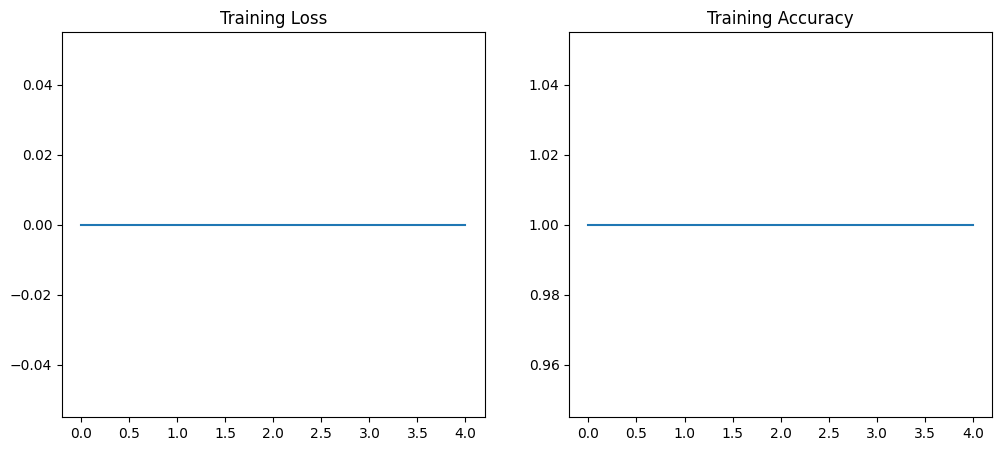

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(accuracies)
plt.title("Training Accuracy")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


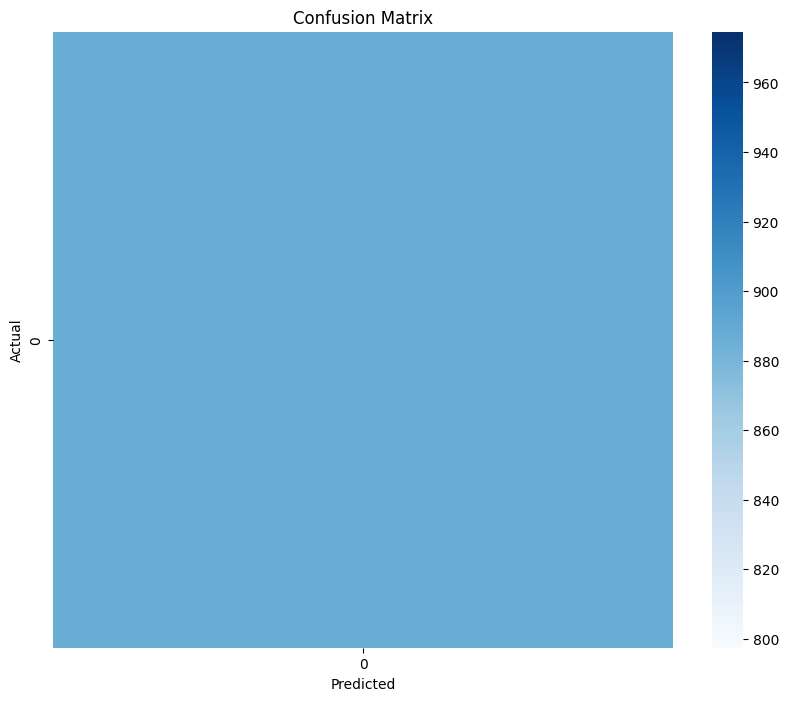

In [10]:
model.eval()
preds, labels_all = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)

        out = model(imgs)
        _, p = torch.max(out, 1)

        preds.extend(p.cpu().numpy())
        labels_all.extend(labels.numpy())

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(labels_all, preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

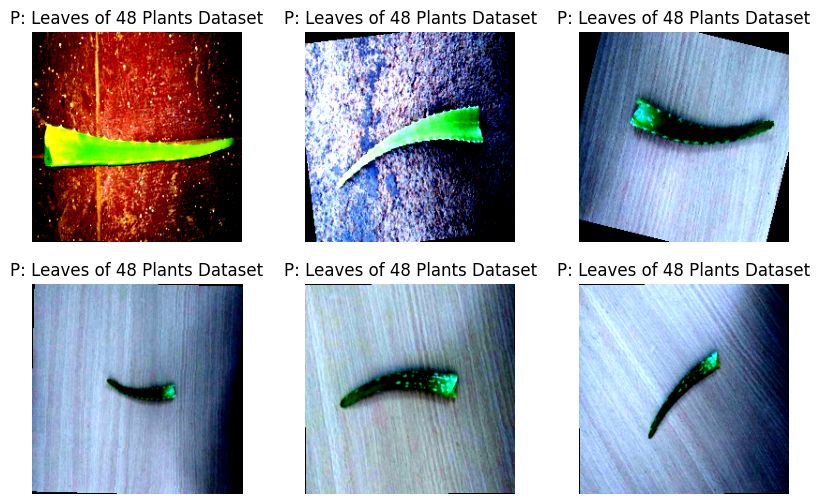

In [11]:
fig, axes = plt.subplots(2,3, figsize=(10,6))

for i in range(6):
    img, label = dataset[i]

    with torch.no_grad():
        out = model(img.unsqueeze(0).to(device))
        _, pred = torch.max(out,1)

    axes[i//3, i%3].imshow(img.permute(1,2,0))
    axes[i//3, i%3].set_title(f"P: {dataset.classes[pred.item()]}")
    axes[i//3, i%3].axis('off')

plt.show()

In [12]:
model.eval()
preds, labels_all = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        _, p = torch.max(out,1)

        preds.extend(p.cpu().numpy())
        labels_all.extend(labels.numpy())

acc = accuracy_score(labels_all, preds)
print("Validation Accuracy:", acc)

Validation Accuracy: 1.0


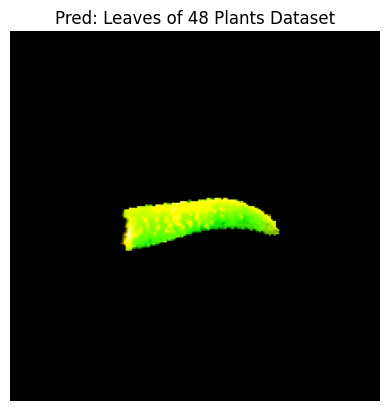

In [13]:
import matplotlib.pyplot as plt

img, label = dataset[10]

model.eval()
with torch.no_grad():
    out = model(img.unsqueeze(0).to(device))
    _, pred = torch.max(out,1)

plt.imshow(img.permute(1,2,0))
plt.title(f"Pred: {dataset.classes[pred.item()]}")
plt.axis('off')
plt.show()